In [1]:
# This is a batch reactor

In [2]:
import cantera as ct
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [3]:
def get_i_thing(ref_composition, phase):
    """Helper function for getting the index of a species in a Cantera phase given its composition"""
    for i in range(phase.n_species):
        if phase.species()[i].composition == ref_composition:
            return i
    assert False, f"Could not find species with composition {ref_composition} in phase {phase.name}"

In [215]:
use_MAP = False

if use_MAP:
    mech_yaml = '/home/moon/uncertainty_estimator/cpox_pt/cpox_pt_20260130/cantera/MAP_mech.yaml'
    mech_name = 'MAP'
else:
    mech_yaml = '/home/moon/uncertainty_estimator/cpox_pt/cpox_pt_20260130/cantera/chem_annotated_mod.yaml'
    mech_name = 'base'

gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "surface1", [gas])

In [216]:
# Flaherty 2011
# uncertainty of 10% in TOF
# https://www-sciencedirect-com.ezproxy.neu.edu/science/article/pii/S0021951711002223#b0150

# ∼350 mL of gas, 1.2% of the volume of the reactor, is withdrawn
# so reactor is 0.350 L / 0.012 = 29.1666667 L
# T = 525–675 K


# Turnover frequencies were calculated by dividing the number of H2 or CO2 molecules produced per second 
# by the number of platinum atoms at the surface, PtS, determined from the product of the exposed
# surface area of the Pt(1 1 1) sample (2.65 cm2) and the atomic density of the Pt(1 1 1) facet (1.50 × 1015 atoms cm−2
#


In [217]:
cat_diameter = 0.013
area = np.pi * np.float_power(cat_diameter / 2.0, 2.0) * 2.0 + 0.001 * np.pi * cat_diameter

In [218]:
area

np.float64(0.00030630528372500485)

In [219]:
# 2.4 mTorr H2 after 10 minutes, or 0.32 Pa, really not much
P_H2_10m = 0.0024 * ct.one_atm / 760

In [220]:
P_H2_10m

0.3199736842105263

In [221]:
volume = 0.0291666667  # m^3
cat_area = 2.65 / 100.0 / 100.0  # convert from cm^2 to m^2
# cat_area = 800  # made-up


# 13mm diameter 1mm thick


P_CO_torr = 25
P_H2O_torr = 15

P_CO = P_CO_torr * ct.one_atm / 760
P_H2O = P_H2O_torr * ct.one_atm / 760
P_total = P_CO + P_H2O

x_CO = P_CO / P_total
x_H2O = P_H2O / P_total

# T = 550
T = 625

In [222]:
# Get indices of key species
i_Ar = get_i_thing({'Ar': 1.0}, gas)
i_CH4 = get_i_thing({'C': 1.0, 'H': 4.0}, gas)
i_O2 = get_i_thing({'O': 2.0}, gas)
i_CO = get_i_thing({'C': 1.0, 'O': 1.0}, gas)
i_H2O = get_i_thing({'H': 2.0, 'O': 1.0}, gas)
i_H2 = get_i_thing({'H': 2.0}, gas)
i_X = get_i_thing({'X': 1.0}, surf)

In [223]:
# Initialize the reactor
X = f'{gas.species_names[i_H2O]}: {x_H2O}, {gas.species_names[i_CO]}: {x_CO}'

gas.TPX = T, P_total, X
surf.TP = T, P_total

initial_coverages = np.zeros_like(surf.coverages)
initial_coverages[i_X] = 1.0
surf.coverages = initial_coverages


r = ct.IdealGasReactor(gas, energy='off')
r.volume = volume
rsurf = ct.ReactorSurface(surf, r, A=cat_area)
sim = ct.ReactorNet([r])

t_end = 80 * 60  # 10 minutes, we won't worry about catalyst poisoning? or that's not what's happening

times = [0]
concs = [gas.X]
Ps = [gas.P]
Ts = [gas.T]
total_moles_H2 = [gas.density_mole * 1000.0 * gas.X[i_H2] * r.volume]
molar_densities = [gas.density_mole * 1000.0]
while sim.time < t_end:
    sim.step()
    times.append(sim.time)
    concs.append(gas.X)
    Ps.append(gas.P)
    Ts.append(gas.T)
    total_moles_H2.append(gas.density_mole * 1000.0 * gas.X[i_H2] * r.volume)
    molar_densities.append(gas.density_mole * 1000.0)
times = np.array(times)
concs = np.array(concs)
Ps = np.array(Ps)
total_moles_H2 = np.array(total_moles_H2)
molar_densities = np.array(molar_densities)
Ts = np.array(Ts)

/tmp/ipykernel_395205/1178930274.py:12: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  r = ct.IdealGasReactor(gas, energy='off')
/tmp/ipykernel_395205/1178930274.py:14: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  rsurf = ct.ReactorSurface(surf, r, A=cat_area)


In [189]:
N_Pt_atoms = cat_area * 1.5e15 * 100 * 100
assert N_Pt_atoms == 2.65 * 1.5e15

In [190]:
N_Pt_atoms

3975000000000000.0

In [203]:
np.multiply(concs[:, 8], Ps) * 760000 / ct.one_atm

array([25000.        , 25000.        , 25000.        , ...,
       24999.99120749, 24999.99120749, 24999.99120749], shape=(1397,))

Text(0.5, 1.0, 'base')

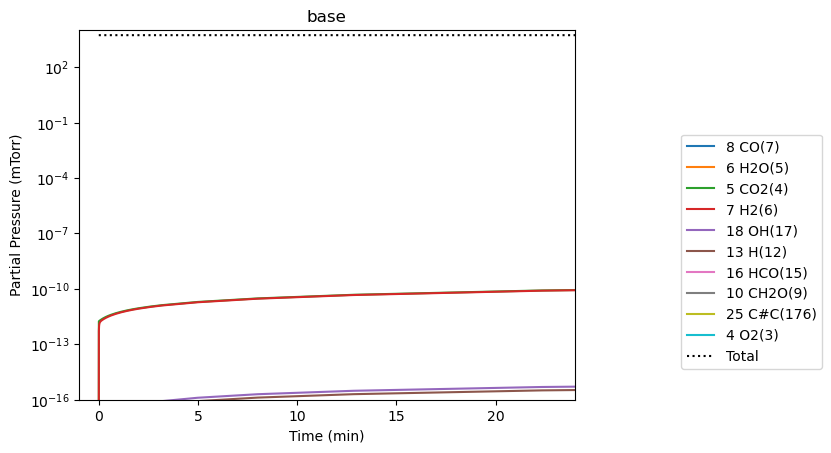

In [224]:
# plot all species vs time
N = 10
max_conc = np.max(concs, axis=0)

indices = np.arange(gas.n_species)
sorted_order = [x for _, x in sorted(zip(max_conc, indices))][::-1]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in range(10):
    j = sorted_order[i]
    # partial_pressures = np.multiply(np.multiply(concs[:, j], molar_densities), Ts) * 8.314  # PV = nRT
    # plt.plot(times / 60.0, partial_pressures, label = gas.species_names[j], color=colors[i])  # yes, these match
    partial_pressures = np.multiply(concs[:, j], Ps) * 760000 / ct.one_atm  # convert to milli-Torr
    plt.plot(times / 60.0, partial_pressures, label = str(j) + ' ' + gas.species_names[j], color=colors[i])

plt.plot(times, Ps, color='black', label='Total', linestyle='dotted')
plt.legend(bbox_to_anchor=(1.2, 0.4))
plt.yscale('log')
plt.ylim([1e-16, 1e4])
plt.ylabel('Partial Pressure (mTorr)')
plt.xlabel('Time (min)')
plt.xlim([-1, 24])
plt.title(mech_name)

In [87]:
concs[:, i_H2]

array([0.00000000e+00, 2.49428367e-59, 4.69316620e-55, ...,
       3.44224438e-09, 3.60065777e-09, 3.75906893e-09], shape=(1452,))

In [170]:
for i in range(gas.n_species):
    print(np.sum(concs[:, i]))
    # if np.sum(concs[:, i]) == 0:
    #     print(gas.species_names[i])

1.2562315825982253e-23
4.9286311977028916e-24
-1.0997325652972804e-23
0.003174404379746959
-5.134800800201188e-25
4.011476200824244
2132.734050056193
3.9519817037041673
358.2993176347251
6.419127099340012e-12
1.649044755221436e-10
7.625385282055862e-16
7.179659454729852e-27
9.497867574957123e-14
7.728483646907203e-23
2.126595284931858e-12
1.0495015473374103e-17
1.5924445370088158e-15
1.0365355251286263e-16
2.6817413807780416e-13
-1.3976759819420059e-30
-1.9949288863637918e-40
1.373296949572766e-31
6.07624938343104e-21
1.917997255250257e-25
2.494484014963018e-18
1.6188474965862694e-32


In [169]:
np.sum(concs[:, 1])

np.float64(4.9286311977028916e-24)

Text(0, 0.5, 'Moles H2')

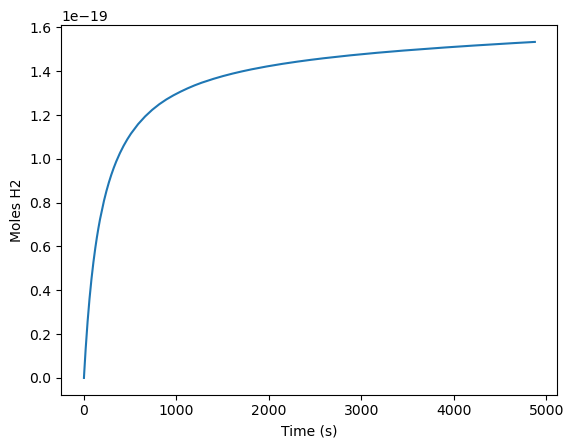

In [36]:
plt.plot(times, total_moles_H2)
plt.xlabel('Time (s)')
plt.ylabel('Moles H2')

In [34]:
# surf.site_density * 1000 / 100 /100 mol/cm^2

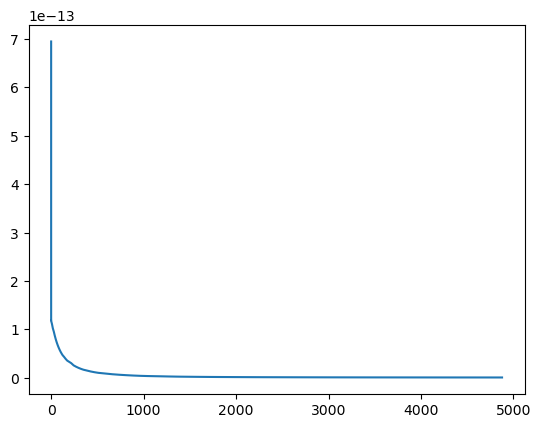

In [39]:
trim_index = int(np.argmin(np.abs(times - 1e-3)))
# trim_index = 0

dt = np.diff(times[trim_index:])
dC_H2 = np.diff(total_moles_H2[trim_index:])  # mols H2


# need to count up the moles of sites

n_sites = surf.site_density * 1000.0 * cat_area # moles sites

# they says it's 1.5e15 atoms / cm^2
# n_sites = 1.5e15 * 2.65

TOF = np.divide(dC_H2, dt) / n_sites


plt.plot(times[trim_index + 1:], TOF)


In [ ]:
times[800]

In [ ]:


# 2.48e-9 / 1e3  # kmol / cm^2
# 2.48e-9 * (100 * 100) / 1e3  # kmol / m^2
sden = surf.site_density * 1000.0 # mol / m^2
n_sites = sden * cat_area  # mol
TOF = np.divide(dC_H2, dt) / n_sites


plt.plot(times[1:], TOF)
# plt.xlim([5, 5000])

In [ ]:
# Initialize the reactor
temperatures = np.array([525.0, 550, 575, 600, 625, 650, 675])
initial_TOFs = np.zeros_like(temperatures)
for tt in range(len(temperatures)):
    T = temperatures[tt]
    X = f'{gas.species_names[i_H2O]}: {x_H2O}, {gas.species_names[i_CO]}: {x_CO}'
    
    gas.TPX = T, P_total, X
    surf.TP = T, P_total
    
    initial_coverages = np.zeros_like(surf.coverages)
    initial_coverages[i_X] = 1.0
    surf.coverages = initial_coverages
    
    
    r = ct.IdealGasReactor(gas, energy='off')
    r.volume = volume
    rsurf = ct.ReactorSurface(surf, r, A=cat_area)
    sim = ct.ReactorNet([r])
    
    t_end = 5 * 60  # 10 minutes, we won't worry about catalyst poisoning? or that's not what's happening
    
    times = [0]
    concs = [gas.X]
    mols_H2 = [gas.density_mole * 1000.0 * gas.X[i_H2] * r.volume]
    while sim.time < t_end:
        sim.step()
    
        times.append(sim.time)
        concs.append(gas.X)
        mols_H2.append(gas.density_mole * 1000.0 * gas.X[i_H2] * r.volume)
    times = np.array(times)
    concs = np.array(concs)
    mols_H2 = np.array(mols_H2)

    # compute TOFs
    dt = np.diff(times)
    dC_H2 = np.diff(mols_H2)
    
    
    # 2.48e-9 / 1e3  # kmol / cm^2
    # 2.48e-9 * (100 * 100) / 1e3  # kmol / m^2
    sden = surf.site_density * 1000.0 # mol / m^2
    mols_sites = sden * cat_area  # mol
    TOF = np.divide(dC_H2, dt) / mols_sites

    # print(tt, TOF[-1])
    initial_TOFs[tt] = TOF[-1] * 1e5

    # plt.plot(times[1:], TOF)
    # plt.xlim([5, 5000])
    

In [ ]:
plt.plot(1000.0 / temperatures, initial_TOFs)
plt.yscale('log')